In [70]:
import pandas as pd
import matplotlib.pyplot as pl
from urllib.parse import quote

base = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query={}&format=csv"

query = """
select
    pl_name,
    sy_name,
    hostname,
    discoverymethod,
    pl_bmassj,
    pl_orbsmax,
    pl_orbper,
    cb_flag
from pscomppars
where
    cb_flag = 1
    and tran_flag=1
"""

planets = pd.read_csv(base.format(quote(query)))

In [71]:
planets

,pl_name,sy_name,hostname,discoverymethod,pl_bmassj,pl_orbsmax,pl_orbper,cb_flag
0,Kepler-47 d,Kepler-47,Kepler-47,Transit,0.059843,0.69920,187.3660,1
1,Kepler-16 b,Kepler-16,Kepler-16,Transit,0.333000,0.70480,228.7760,1
2,Kepler-47 c,Kepler-47,Kepler-47,Transit,0.009974,0.96380,303.2270,1
3,Kepler-38 b,Kepler-38,Kepler-38,Transit,0.384000,0.46320,105.5990,1
4,Kepler-47 b,Kepler-47,Kepler-47,Transit,0.006513,0.28770,49.4643,1
5,Kepler-413 b,Kepler-413,Kepler-413,Transit,0.211000,0.35530,66.2620,1
6,Kepler-34 b,Kepler-34,Kepler-34,Transit,0.220000,1.08960,288.8220,1
7,Kepler-35 b,Kepler-35,Kepler-35,Transit,0.127000,0.60347,131.4580,1
8,Kepler-1661 b,Kepler-1661,Kepler-1661,Transit,0.053488,0.63300,175.0600,1
9,Kepler-453 b,Kepler-453,Kepler-453,Transit,0.050341,0.79030,240.5030,1


In [69]:
query = """
select top 1 *
from pscomppars
"""

df = pd.read_csv(base.format(quote(query)))
print(df.columns.tolist())

['systemid', 'sy_name', 'objectid', 'pl_name', 'pl_letter', 'hostid', 'hostname', 'hd_name', 'hip_name', 'tic_id', 'gaia_dr2_id', 'ttv_flag', 'ptv_flag', 'tran_flag', 'rv_flag', 'ast_flag', 'obm_flag', 'micro_flag', 'etv_flag', 'ima_flag', 'dkin_flag', 'pul_flag', 'pl_controv_flag', 'pl_pubdate', 'disc_pubdate', 'disc_year', 'disc_refid', 'disc_method', 'discoverymethod', 'disc_locale', 'disc_facility', 'disc_instrument', 'disc_telescope', 'disc_refname', 'sy_snum', 'sy_pnum', 'sy_mnum', 'cb_flag', 'st_nphot', 'st_nrvc', 'st_nspec', 'pl_nespec', 'pl_ntranspec', 'pl_nnotes', 'ra', 'raerr1', 'raerr2', 'rasymerr', 'rastr', 'ra_solnid', 'ra_reflink', 'dec', 'decerr1', 'decerr2', 'decsymerr', 'decstr', 'dec_solnid', 'dec_reflink', 'glon', 'glonerr1', 'glonerr2', 'glonsymerr', 'glonstr', 'glon_solnid', 'glon_reflink', 'glat', 'glaterr1', 'glaterr2', 'glatsymerr', 'glatstr', 'glat_solnid', 'glat_reflink', 'elon', 'elonerr1', 'elonerr2', 'elonsymerr', 'elonstr', 'elon_solnid', 'elon_reflink', 

In [66]:
planets.sort_values(["sy_name"])

,pl_name,sy_name,hostname,discoverymethod,pl_bmassj,pl_orbsmax,pl_orbper,cb_flag
1,Kepler-16 b,Kepler-16,Kepler-16,Transit,0.333000,0.70480,228.7760,1
10,Kepler-1647 b,Kepler-1647,Kepler-1647,Transit,1.519680,2.72050,1107.5923,1
8,Kepler-1661 b,Kepler-1661,Kepler-1661,Transit,0.053488,0.63300,175.0600,1
6,Kepler-34 b,Kepler-34,Kepler-34,Transit,0.220000,1.08960,288.8220,1
7,Kepler-35 b,Kepler-35,Kepler-35,Transit,0.127000,0.60347,131.4580,1
3,Kepler-38 b,Kepler-38,Kepler-38,Transit,0.384000,0.46320,105.5990,1
5,Kepler-413 b,Kepler-413,Kepler-413,Transit,0.211000,0.35530,66.2620,1
9,Kepler-453 b,Kepler-453,Kepler-453,Transit,0.050341,0.79030,240.5030,1
0,Kepler-47 d,Kepler-47,Kepler-47,Transit,0.059843,0.69920,187.3660,1
2,Kepler-47 c,Kepler-47,Kepler-47,Transit,0.009974,0.96380,303.2270,1


# Legacy
星の情報をとってこようと思ったけど上手くいかなかったやつ

In [53]:
systems = planets["sy_name"].unique()
systems_sql = ",".join([f"'{s}'" for s in systems])

query = f"""
select
    sy_name,
    hostname,
    st_mass,
    st_teff,
    st_refname
from stellarhosts
where
    sy_name in ({systems_sql})
"""

stars = pd.read_csv(base.format(quote(query)))

In [61]:
stars_clean = (
    stars.dropna(subset=["st_mass"])
         .sort_values(["sy_name", "hostname","st_refname"])
)

stars_clean = stars_clean.reset_index(drop=True)

In [62]:
stars_clean

,sy_name,hostname,st_mass,st_teff,st_refname
0,Kepler-16,Kepler-16,0.6897,4450.0,<a refstr=DOYLE_ET_AL__2011 href=https://ui.ad...
1,Kepler-16,Kepler-16,0.6300,4452.0,<a refstr=Q1_Q12_KOI_TABLE href=https://exopla...
2,Kepler-16,Kepler-16,0.6300,4452.0,<a refstr=Q1_Q16_KOI_TABLE href=https://exopla...
3,Kepler-16,Kepler-16,0.6300,4452.0,<a refstr=Q1_Q17_DR24_KOI_TABLE href=https://e...
4,Kepler-16,Kepler-16,0.6330,4451.0,<a refstr=Q1_Q17_DR25_KOI_TABLE href=https://e...
...,...,...,...,...,...
105,TOI-1338,TOI-1338 A,1.0200,5723.2,<a refstr=STASSUN_ET_AL__2019 href=https://ui....
106,TOI-1338,TOI-1338 A,1.0936,NaN,<a refstr=WANG__AMP__LIU_2024 href=https://ui....
107,TOI-1338,TOI-1338 B,0.3128,NaN,<a refstr=KOSTOV_ET_AL__2020 href=https://ui.a...
108,TOI-1338,TOI-1338 B,0.3130,NaN,<a refstr=STANDING_ET_AL_2023 href=https://ui....


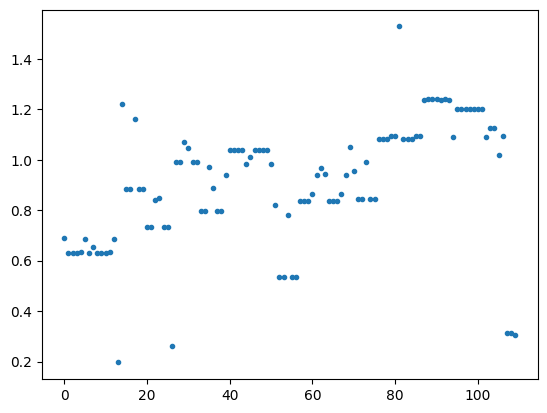

In [63]:
pl.plot(stars_clean['st_mass'],'.')

In [64]:
stars[stars.sy_name=="Kepler-16"][
    ["hostname","st_mass","st_refname"]
]

,hostname,st_mass,st_refname
12,Kepler-16,0.6300,<a refstr=Q1_Q17_DR24_KOI_TABLE href=https://e...
18,Kepler-16,0.6550,<a refstr=TRIAUD_ET_AL__2022 href=https://ui.a...
22,Kepler-16,NaN,<a refstr=LATHAM_ET_AL__2005 href=https://ui.a...
25,Kepler-16,0.6860,<a refstr=Q1_Q8_KOI_TABLE href=https://exoplan...
28,Kepler-16,0.6300,<a refstr=STASSUN_ET_AL__2019 href=https://ui....
34,Kepler-16,0.6897,<a refstr=DOYLE_ET_AL__2011 href=https://ui.ad...
57,Kepler-16 B,0.1965,<a refstr=TRIAUD_ET_AL__2022 href=https://ui.a...
73,Kepler-16 B,0.6300,<a refstr=Q1_Q12_KOI_TABLE href=https://exopla...
74,Kepler-16 B,NaN,<a refstr=Q1_Q17_DR25_SUPPLEMENTAL_KOI_TABLE h...
77,Kepler-16 B,0.6330,<a refstr=Q1_Q17_DR25_KOI_TABLE href=https://e...


In [32]:
stars[stars.sy_name=="Kepler-16"][
    ["hostname","st_mass","st_refname"]
]

KeyError: "['st_refname'] not in index"